## Figure 1

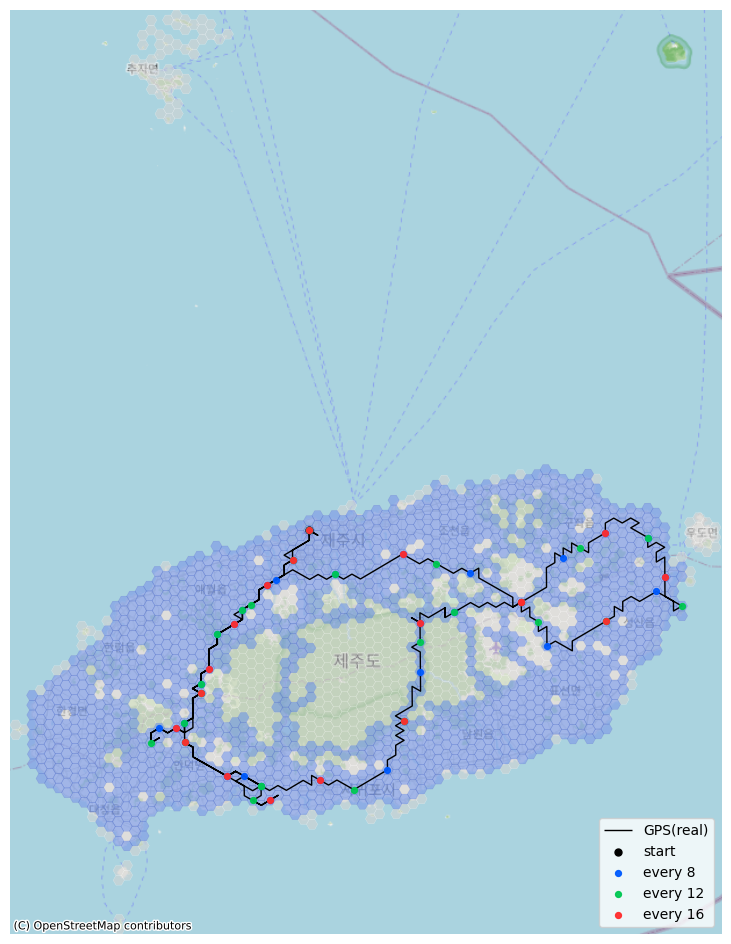

finished: ./fig_routes/real_only_i15_hex_MATCH_CODE1_SCALE.png


In [1]:
# -*- coding: utf-8 -*-
import os
import ast
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from shapely.geometry import LineString
import contextily as ctx

# Levenshtein Distance (likewise with Jaccard)
BASE_HEX_PATH   = "./new_hexagraph/jeju_hexa_for_use.shp"
BLUE_HEX_PATH   = "./new_hexagraph/hexa_network_with_road.shp"
REAL_GPS_TMPL   = "./GPS_trajectory_for_figure/Figure_1/merged_routes_by_{k}.csv"

# Parameters
for i_person in [15]:               # Index of the selected traveler row
    OUT_DIR = "./fig_routes"
    os.makedirs(OUT_DIR, exist_ok=True)

    # Load data and set CRS 
    base_hex = gpd.read_file(BASE_HEX_PATH)
    blue_hex = gpd.read_file(BLUE_HEX_PATH)
    assert "new_id" in blue_hex.columns, "'new_id' column is required."

    # Change CRS to Web Mercator (EPSG:3857) for accurate distance-based sampling
    base_web = base_hex.to_crs(epsg=3857)
    blue_web = blue_hex.to_crs(epsg=3857)
    blue_idx = blue_web.set_index("new_id")

    xmin, ymin, xmax, ymax = base_web.total_bounds


    real_csv = None
    for k_try in [8, 12, 16]:
        candidate = REAL_GPS_TMPL.format(k=k_try)
        if os.path.exists(candidate):
            real_csv = candidate
            break
    if real_csv is None:
        raise FileNotFoundError("No real GPS CSV file found for k=8, 12, or 16.")

    real_df = pd.read_csv(real_csv)

    # utility functions
    def path_to_linestring(id_path, gdf_indexed):
        valid = [p for p in id_path if p in gdf_indexed.index]
        if len(valid) < 2:
            return None, None
        sub = gdf_indexed.loc[valid].copy()
        cents = sub.geometry.centroid
        line = LineString(cents.tolist())
        return line, cents

    def sample_every(cents, step):
        if cents is None or len(cents) == 0:
            return gpd.GeoSeries([], crs=3857)
        idxs = list(range(0, len(cents), step))
        return gpd.GeoSeries(cents.iloc[idxs].values, crs=3857)

    # ith person's path
    if i_person >= len(real_df):
        raise IndexError(f"i_person={i_person} exceeds the number of rows in real_df ({len(real_df)}).")

    real_path = ast.literal_eval(real_df.iloc[i_person, 1])
    real_line, real_cents = path_to_linestring(real_path, blue_idx)
    if real_line is None:
        raise ValueError("The real path does not contain enough valid hex IDs to form a LineString.")

    # visualization
    fig, ax = plt.subplots(figsize=(12, 12))
    HALO = [pe.Stroke(linewidth=4.5, foreground="white"), pe.Normal()]

    base_web.plot(ax=ax, facecolor="lightgray", edgecolor="white",
                  linewidth=0.2, alpha=0.6, zorder=1)

    blue_web.plot(ax=ax, facecolor="#2F6BFF", edgecolor="#1E40AF",
                  linewidth=0.3, alpha=0.35, zorder=2)

    gpd.GeoSeries([real_line], crs=3857).plot(
        ax=ax, color="#000000", linewidth=1.0, alpha=1.0,  # ← "#000000"로 보정
        zorder=9, label="GPS(real)"
    )

    if real_cents is not None and len(real_cents) > 0:
        gpd.GeoSeries([real_cents.iloc[0]], crs=3857).plot(
            ax=ax, color="black", markersize=25, zorder=10, label="start"
        )

    pts_8  = sample_every(real_cents, 8)
    pts_12 = sample_every(real_cents, 12)
    pts_16 = sample_every(real_cents, 16)

    if len(pts_8) > 0:
        pts_8.plot(ax=ax, marker='o', markersize=18, color="#005BFF", alpha=0.95,
                   zorder=11, label="every 8")
    if len(pts_12) > 0:
        pts_12.plot(ax=ax, marker='o', markersize=18, color="#00C853", alpha=0.95,
                    zorder=12, label="every 12")
    if len(pts_16) > 0:
        pts_16.plot(ax=ax, marker='o', markersize=18, color="#FF2D2D", alpha=0.95,
                    zorder=13, label="every 16")


    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, reset_extent=False)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_axis_off()
    plt.legend(fontsize=10, loc="lower right")

    out_png = os.path.join(OUT_DIR, f"real_only_i{i_person}_hex_MATCH_CODE1_SCALE.png")
    plt.savefig(out_png, dpi=300)
    plt.show()

    print(f"finished: {out_png}")


## Figure 6

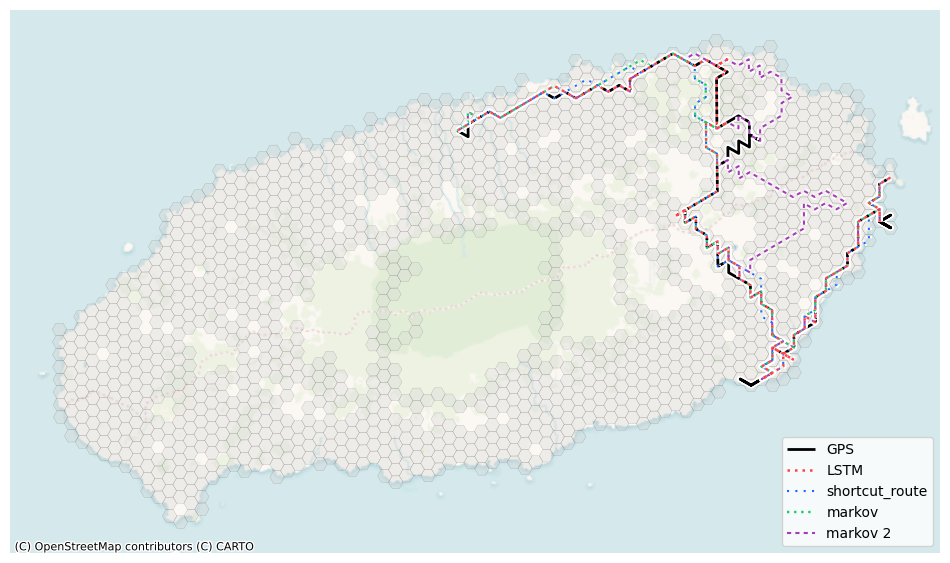

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import torch
import ast
import re
from shapely.geometry import LineString
from shapely.affinity import translate
import contextily as ctx
import matplotlib.font_manager as fm
import matplotlib as mpl
from matplotlib.patches import Rectangle
from torch_geometric.data import Data
import os
import matplotlib.patheffects as pe
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

gdf = gpd.read_file("./new_hexagraph/hexa_network_with_road.shp")
gdf_web = gdf.to_crs(epsg=3857)

for l in [0]:
    for k in [12]:
        
        # LSTM
        pred_df = pd.read_csv(f'./GPS_trajectory_for_figure/Figure_6/LSTM_fix_{k}_by1.csv')
        pred_path = ast.literal_eval(pred_df.iloc[l, 1])
        pred_gdf = gdf.set_index('new_id').loc[pred_path].reset_index().to_crs(epsg=3857)
        pred_centroids = pred_gdf.geometry.centroid
        pred_line = LineString(pred_centroids.tolist())
        
        # GPS
        real_df = pd.read_csv(f'./GPS_trajectory_for_figure/Figure_6/merged_routes_by_{k}.csv')
        real_path = ast.literal_eval(real_df.iloc[l, 1])
        real_gdf = gdf.set_index('new_id').loc[real_path].reset_index().to_crs(epsg=3857)
        real_centroids = real_gdf.geometry.centroid
        real_line = LineString(real_centroids.tolist())
        real_line_offset = translate(real_line, xoff=5, yoff=5)
        
        # Shortcut
        shortcut_df = pd.read_csv(f'./GPS_trajectory_for_figure/Figure_6/shortcut_path_{k}.csv')
        shortcut_path = ast.literal_eval(shortcut_df.iloc[l, 1])
        shortcut_gdf = gdf.set_index('new_id').loc[shortcut_path].reset_index().to_crs(epsg=3857)
        shortcut_centroids = shortcut_gdf.geometry.centroid
        shortcut_line = LineString(shortcut_centroids.tolist())
        shortcut_line_offset = translate(shortcut_line, xoff=-5, yoff=-5)
        
        # Markov
        markov_df = pd.read_csv(f'./GPS_trajectory_for_figure/Figure_6/markov_route_{k}.csv')
        markov_path = ast.literal_eval(markov_df.iloc[l, 1])
        markov_path = [int(x) for x in markov_path]
        markov_gdf = gdf.set_index('new_id').loc[markov_path].reset_index().to_crs(epsg=3857)
        markov_centroids = markov_gdf.geometry.centroid
        markov_line = LineString(markov_centroids.tolist())
        markov_line_offset = translate(markov_line, xoff=-5, yoff=-5)

        # Attribute Conditioned Markov
        markov_2_df = pd.read_csv(f'./GPS_trajectory_for_figure/Figure_6/markov2_route_{k}.csv')
        markov_2_path = ast.literal_eval(markov_2_df.iloc[l, 1])
        markov_2_path = [int(x) for x in markov_2_path]
        markov_2_gdf = gdf.set_index('new_id').loc[markov_2_path].reset_index().to_crs(epsg=3857)
        markov_2_centroids = markov_2_gdf.geometry.centroid
        markov_2_line = LineString(markov_2_centroids.tolist())
        markov_2_line_offset = translate(markov_2_line, xoff=-5, yoff=-5)

        # Visualization
        fig, ax = plt.subplots(figsize=(12, 12))
        halo = [pe.Stroke(linewidth=4.5, foreground='white'), pe.Normal()]
        gdf_web.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, linewidth=0.2)
        COL_LSTM     = '#FF2D2D'  # vivid red
        COL_SHORTCUT = '#005BFF'  # vivid blue
        COL_MARKOV   = '#00C853'  # vivid green
        COL_MARKOV2 = '#9C27B0'  # vivid purple/magenta
        LS_DOT_WIDE_1 = (0, (1, 2))
        LS_DOT_WIDE_2 = (0, (1, 3))
        LS_DOT_WIDE_3 = (0, (2, 2))

        gpd.GeoSeries([real_line_offset], crs=3857).plot(
            ax=ax, color='#000000', linewidth=2.0, alpha=1.0,
            zorder=5, label='GPS', path_effects=halo
        )
        gpd.GeoSeries([pred_line], crs=3857).plot(
            ax=ax, color=COL_LSTM, linewidth=1.8, alpha=0.9,
            linestyle=LS_DOT_WIDE_1,
            zorder=9, label='LSTM', path_effects=halo
        )
        gpd.GeoSeries([shortcut_line_offset], crs=3857).plot(
            ax=ax, color=COL_SHORTCUT, linewidth=1.5, alpha=0.9,
            linestyle=LS_DOT_WIDE_2,
            zorder=8, label='shortcut_route', path_effects=halo
        )
        gpd.GeoSeries([markov_line_offset], crs=3857).plot(
            ax=ax, color=COL_MARKOV, linewidth=1.7, alpha=0.9,
            linestyle=LS_DOT_WIDE_1,
            zorder=7, label='markov', path_effects=halo
        )
        gpd.GeoSeries([markov_2_line_offset], crs=3857).plot(
            ax=ax, color=COL_MARKOV2, linewidth=1.5, alpha=0.9,
            linestyle=LS_DOT_WIDE_3,
            zorder=6, label='markov 2', path_effects=halo
        )

        # Start/End Points (based on predicted path)
        # pred_centroids.iloc[[0]].plot(ax=ax, color='black', markersize=20, label='start point')
        # markov_centroids.iloc[[0]].plot(ax=ax, color='green', markersize=20, label='start point')
        # real_centroids.iloc[[0]].plot(ax=ax, color='blue', markersize=20, label='start point')
        # shortcut_centroids.iloc[[0]].plot(ax=ax, color='black', markersize=20, label='start point')
        # markov_2_centroids.iloc[[0]].plot(ax=ax, color='yellow', markersize=20, label='start point')

        # OSM
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.VoyagerNoLabels)
        plt.axis('off')
        plt.legend(fontsize=10, loc='lower right')
        plt.savefig(f'predict_map_{k}.png', dpi=300)
        plt.show()

## Figure 9

/tmp/ipykernel_1568141/138146506.py:129: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10")


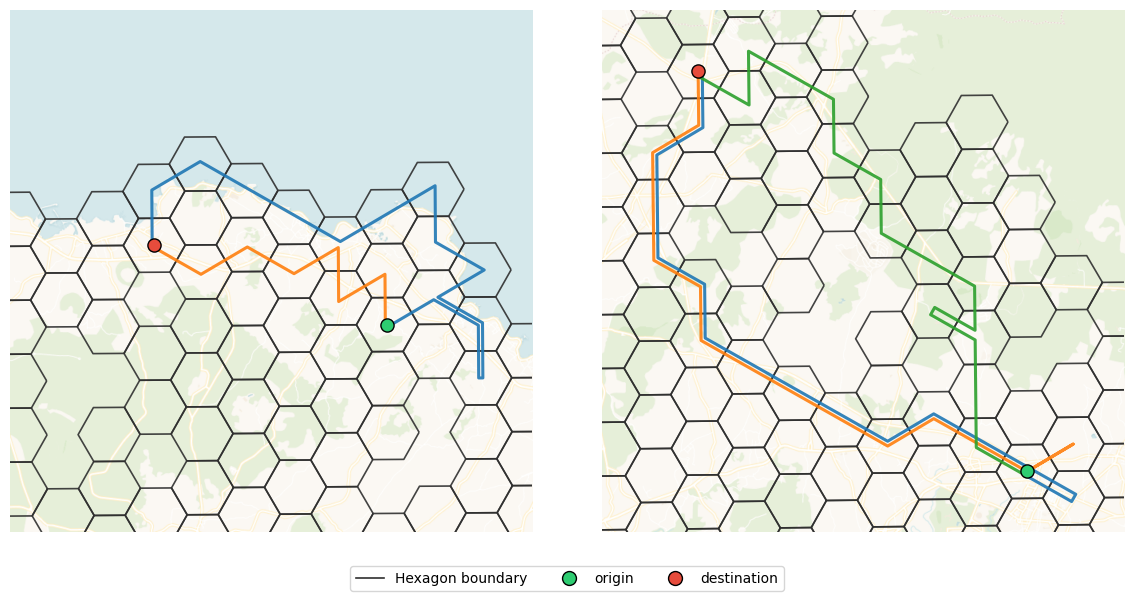

In [ ]:
import os
import glob
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import contextily as ctx
from shapely.geometry import LineString, Point
from matplotlib.lines import Line2D

# trajectory path
GROUP_DIRS = [
    "./GPS_trajectory_for_figure/Figure_9/group_1",
    "./GPS_trajectory_for_figure/Figure_9/group_2",
]

# heaxagon with road
gdf = gpd.read_file("./new_hexagraph/hexa_network_with_road.shp")
gdf_web = gdf.to_crs(epsg=3857)

gdf_idx = gdf_web.set_index("new_id", drop=False)
centroid_by_id = {
    idx: geom.centroid
    for idx, geom in zip(gdf_idx.index, gdf_idx.geometry)
}

# utility functions
def get_centroid(pid):
    return centroid_by_id.get(int(pid), None)

def read_seq(csv_path):
    d = pd.read_csv(csv_path)

    if "path" not in d.columns or d.empty:
        return None

    return d["path"].tolist()

def seq_to_line(seq):
    pts = [get_centroid(p) for p in seq if get_centroid(p) is not None]
    return LineString(pts) if len(pts) >= 2 else None

def collect_lines_from_folder(route_dir):
    csv_files = sorted(glob.glob(os.path.join(route_dir, "*.csv")))

    lines = []

    for fpath in csv_files:
        seq = read_seq(fpath)
        if seq is None:
            continue

        line = seq_to_line(seq)
        if line is not None:
            lines.append(line)

    return lines

def bounds_from(lines, start=None, end=None):
    geoms = list(lines)

    if start is not None:
        geoms.append(Point(start.x, start.y))

    if end is not None:
        geoms.append(Point(end.x, end.y))

    if len(geoms) == 0:
        raise ValueError("그릴 수 있는 경로가 없습니다. CSV 파일의 path 열과 헥사곤 new_id 매칭을 확인하십시오.")

    return gpd.GeoSeries(geoms, crs=gdf_web.crs).total_bounds

def get_start_end_from_lines(lines):
    if len(lines) == 0:
        return None, None

    first_line = lines[0]
    start = Point(first_line.coords[0])
    end = Point(first_line.coords[-1])

    return start, end


# group_1 / group_2 trajectory
packs = []
bounds_list = []

for group_dir in GROUP_DIRS:
    lines = collect_lines_from_folder(group_dir)
    start, end = get_start_end_from_lines(lines)

    packs.append((lines, start, end))
    bounds_list.append(bounds_from(lines, start, end))

# boundary and design
ws = [b[2] - b[0] for b in bounds_list]
hs = [b[3] - b[1] for b in bounds_list]
base = max(max(ws), max(hs), 600)

PAD = 0.15
half = base * (1 + PAD) / 2

HEX_COLOR = "#2f2f2f"
HEX_WIDTH = 1.2

START_COLOR = "#2ECC71"
END_COLOR   = "#E74C3C"

BASEMAP = ctx.providers.CartoDB.VoyagerNoLabels

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.01)

cmap = cm.get_cmap("tab10")

for ax, pack, b in zip(axes, packs, bounds_list):

    lines, start_c, end_c = pack

    cx = (b[0] + b[2]) / 2
    cy = (b[1] + b[3]) / 2

    xmin, xmax = cx - half, cx + half
    ymin, ymax = cy - half, cy + half

    # -------- 중요 --------
    # 먼저 extent 설정
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # -------- 배경 --------
    ctx.add_basemap(
        ax,
        source=BASEMAP,
        crs=gdf_web.crs,
        attribution=False,
        zoom='auto'
    )

    # -------- hexagon --------
    gdf_web.boundary.plot(
        ax=ax,
        edgecolor=HEX_COLOR,
        linewidth=HEX_WIDTH,
        alpha=0.9,
        zorder=2
    )

    OFFSET_STEP = 100   # meter

    n = len(lines)
    center = (n - 1) / 2

    for i, geom in enumerate(lines):

        offset_dist = (i - center) * OFFSET_STEP

        if offset_dist == 0:
            shifted = geom
        else:
            side = "left" if offset_dist > 0 else "right"
            shifted = geom.parallel_offset(
                abs(offset_dist),
                side,
                join_style=2
            )

            if shifted.geom_type == "MultiLineString":
                shifted = max(shifted.geoms, key=lambda g: g.length)

        gpd.GeoSeries([shifted], crs=gdf_web.crs).plot(
            ax=ax,
            color=cmap(i),
            linewidth=2.2,
            alpha=0.9,
            zorder=5
        )

    # -------- start / end --------
    if start_c is not None:
        ax.scatter(
            start_c.x, start_c.y,
            s=90,
            c=START_COLOR,
            edgecolors="black",
            zorder=10
        )

    if end_c is not None:
        ax.scatter(
            end_c.x, end_c.y,
            s=90,
            c=END_COLOR,
            edgecolors="black",
            zorder=10
        )

    ax.set_axis_off()

# =========================
# legend
# =========================
legend_items = [
    Line2D([0], [0], color=HEX_COLOR, lw=HEX_WIDTH, label="Hexagon boundary"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=START_COLOR,
           markeredgecolor='black', markersize=10, label="origin"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=END_COLOR,
           markeredgecolor='black', markersize=10, label="destination"),
]

fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=3,
    frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## Figure 10

cases: 2
method        file_name  start  end
0       e013135_1_0.csv   1242  940
1       h000235_1_4.csv   1242  940


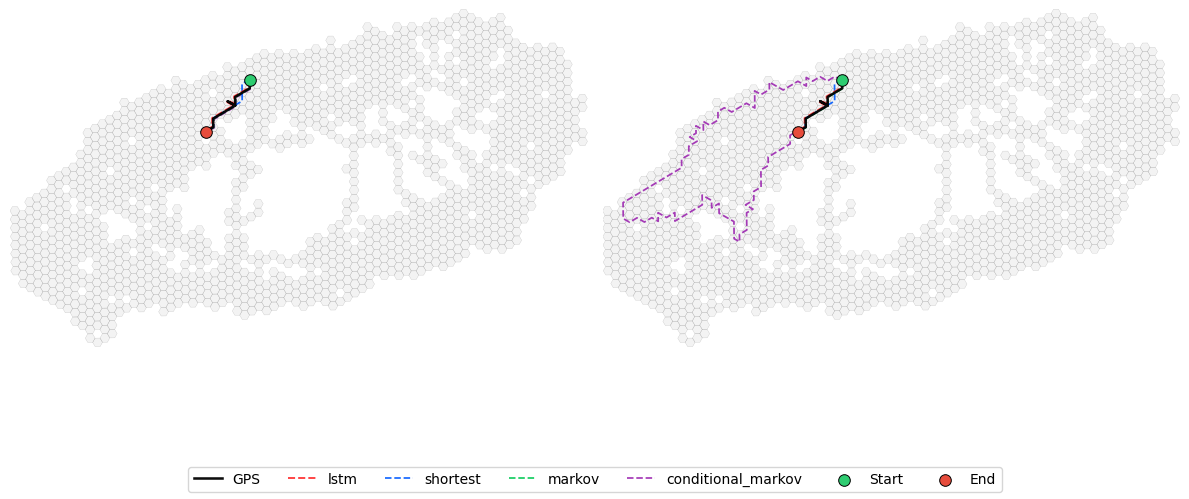

In [ ]:
# -*- coding: utf-8 -*-
import os
import ast
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from shapely.errors import ShapelyDeprecationWarning
import warnings

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

# parhs and files
GEN_CSV = "./GPS_trajectory_for_figure/Figure_10/all_multi_route_generated_routes_parallel.csv"
GPS_CSV_DIR = "./GPS_trajectory_for_figure/Figure_10"
SHP_PATH = "./new_hexagraph/hexa_network_with_road.shp"

TARGET_FILES = [
    "e013135_1_0.csv",
    "h000235_1_4.csv",
]

SAVE_FIG = False
OUT_FIG = "./selected_route_comparison.png"

# visualization parameters
COLORS = {
    "GPS":      "#000000",
    "lstm":     "#FF2D2D",
    "shortest": "#005BFF",
    "markov":   "#00C853",
    "markov2":  "#9C27B0",
}

WIDTHS = {
    "GPS":      1.6,
    "lstm":     1.2,
    "shortest": 1.1,
    "markov":   1.1,
    "markov2":  1.1,
}

LS_DASH = "--"
W_SCALE = 1.15

LABEL_MAP = {
    "markov2": "conditional_markov"
}

OFFSET_STEP_M = 100
OFFSET_METHODS = {"lstm", "shortest", "markov", "markov2"}
OFFSET_JOIN_STYLE = 2

gdf = gpd.read_file(SHP_PATH)
gdf_web = gdf.to_crs(epsg=3857)

if "new_id" not in gdf_web.columns:
    raise ValueError("shp에 new_id 컬럼이 없습니다.")

gdf_idx = gdf_web.set_index("new_id", drop=False)

centroid_by_id = {
    int(i): geom.centroid
    for i, geom in zip(gdf_idx["new_id"], gdf_idx.geometry)
}


XMIN, YMIN, XMAX, YMAX = gdf_web.total_bounds

# utility functions
def safe_parse_list(x):
    if isinstance(x, list):
        return x

    try:
        v = ast.literal_eval(x)
        return v if isinstance(v, list) else []
    except Exception:
        return []


def path_to_line(path):
    pts = []

    for p in path:
        try:
            pid = int(p)
        except Exception:
            continue

        c = centroid_by_id.get(pid)

        if c is not None:
            pts.append(c)

    return LineString(pts) if len(pts) >= 2 else None


def load_gps_path(file_name):
    fpath = os.path.join(GPS_CSV_DIR, file_name)

    if not os.path.exists(fpath):
        raise FileNotFoundError(f"GPS CSV 파일을 찾을 수 없습니다: {fpath}")

    d = pd.read_csv(fpath)

    if "path" not in d.columns:
        raise ValueError(f"{file_name} 파일에 path 컬럼이 없습니다.")

    return d["path"].dropna().astype(int).tolist()


def offset_linestring(line, offset_dist_m):
    if line is None:
        return None

    if abs(offset_dist_m) < 1e-9:
        return line

    try:
        side = "left" if offset_dist_m > 0 else "right"

        shifted = line.parallel_offset(
            abs(offset_dist_m),
            side=side,
            join_style=OFFSET_JOIN_STYLE
        )

        if shifted is None:
            return line

        if shifted.geom_type == "MultiLineString":
            shifted = max(
                list(shifted.geoms),
                key=lambda g: g.length,
                default=line
            )

        return shifted

    except Exception:
        return line


# drawing
df = pd.read_csv(GEN_CSV)

need = {"start", "end", "file_name", "generated_route", "method"}
missing = need - set(df.columns)

if missing:
    raise ValueError(f"GEN_CSV에 필요한 컬럼이 없습니다: {missing}")

df["route"] = df["generated_route"].apply(safe_parse_list)

sub = df[df["file_name"].isin(TARGET_FILES)].copy()

if sub.empty:
    raise RuntimeError("TARGET_FILES에 해당하는 generated route가 없습니다.")

pivot = (
    sub.pivot_table(
        index=["start", "end", "file_name"],
        columns="method",
        values="route",
        aggfunc="first"
    )
    .reset_index()
)

pivot["file_order"] = pivot["file_name"].apply(
    lambda x: TARGET_FILES.index(x) if x in TARGET_FILES else 999
)

pivot = (
    pivot
    .sort_values("file_order")
    .drop(columns="file_order")
    .reset_index(drop=True)
)

for m in ["shortest", "markov", "markov2", "lstm"]:
    if m not in pivot.columns:
        pivot[m] = None

pivot["gps"] = pivot["file_name"].apply(load_gps_path)

print("cases:", len(pivot))
print(pivot[["file_name", "start", "end"]])

n = len(pivot)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))

if n == 1:
    axes = [axes]

for i, row in pivot.iterrows():
    ax = axes[i]

    gdf_web.plot(
        ax=ax,
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.25,
        linewidth=0.2,
        zorder=1
    )

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_axis_off()

    method_order = ["lstm", "shortest", "markov", "markov2"]
    center = (len(method_order) - 1) / 2.0

    method_offset = {
        m: (j - center) * OFFSET_STEP_M
        for j, m in enumerate(method_order)
    }

    gps = row["gps"] if isinstance(row.get("gps"), list) else []
    gps_line = path_to_line(gps)

    if gps_line is not None:
        ax.plot(
            *gps_line.xy,
            color=COLORS["GPS"],
            linewidth=WIDTHS["GPS"] * W_SCALE,
            linestyle="-",
            alpha=0.95,
            zorder=10,
            label="GPS"
        )

    def draw(route, key, z):
        if not isinstance(route, list) or len(route) < 2:
            return

        line = path_to_line(route)

        if line is None:
            return

        if key in OFFSET_METHODS:
            line = offset_linestring(
                line,
                method_offset.get(key, 0.0)
            )

        label = LABEL_MAP.get(key, key)

        ax.plot(
            *line.xy,
            color=COLORS[key],
            linewidth=WIDTHS[key] * W_SCALE,
            linestyle=LS_DASH,
            alpha=0.9,
            zorder=z,
            label=label
        )

    draw(row.get("lstm"),     "lstm",     9)
    draw(row.get("shortest"), "shortest", 8)
    draw(row.get("markov"),   "markov",   7)
    draw(row.get("markov2"),  "markov2",  6)

    if isinstance(gps, list) and len(gps) >= 2:
        sp = centroid_by_id.get(int(gps[0]))
        ep = centroid_by_id.get(int(gps[-1]))
    else:
        sp = centroid_by_id.get(int(row["start"]))
        ep = centroid_by_id.get(int(row["end"]))

    if sp is not None:
        ax.scatter(
            [sp.x], [sp.y],
            s=70,
            c="#2ECC71",
            edgecolors="black",
            linewidths=0.7,
            zorder=30,
            label="Start"
        )

    if ep is not None:
        ax.scatter(
            [ep.x], [ep.y],
            s=70,
            c="#E74C3C",
            edgecolors="black",
            linewidths=0.7,
            zorder=30,
            label="End"
        )

handles, labels = axes[0].get_legend_handles_labels()

seen = set()
uh, ul = [], []

for h, l in zip(handles, labels):
    if l and l not in seen:
        uh.append(h)
        ul.append(l)
        seen.add(l)

fig.legend(
    uh,
    ul,
    loc="lower center",
    ncol=7,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

if SAVE_FIG:
    plt.savefig(
        OUT_FIG,
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

## Figure 11

cases: 2
['h000108_3_0.csv', 'h004703_6_0.csv']


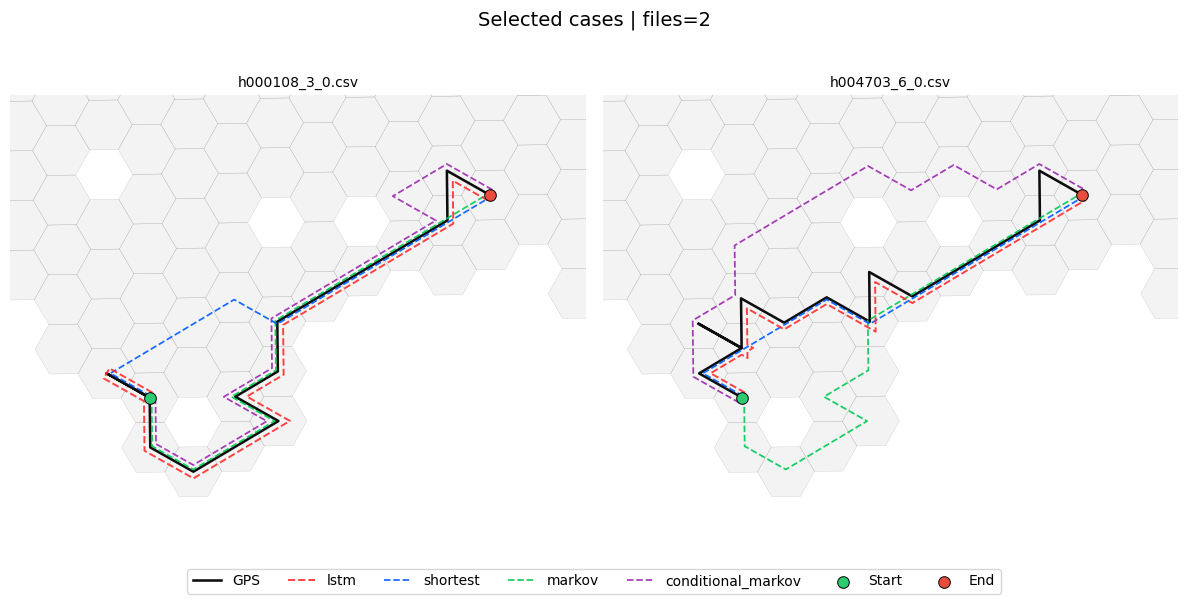

In [ ]:
# -*- coding: utf-8 -*-
import os
import ast
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from shapely.errors import ShapelyDeprecationWarning
import warnings

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

# path and files
GEN_CSV = "./GPS_trajectory_for_figure/Figure_11/all_multi_route_generated_routes_parallel.csv"
GPS_TRAJ_DIR = "./GPS_trajectory_for_figure/Figure_11"
SHP_PATH = "./new_hexagraph/hexa_network_with_road.shp"
TARGET_FILES = [
    "h000108_3_0.csv",
    "h004703_6_0.csv",
]

# visualization parameters
COLORS = {
    "GPS":      "#000000",
    "lstm":     "#FF2D2D",
    "shortest": "#005BFF",
    "markov":   "#00C853",
    "markov2":  "#9C27B0",
}

WIDTHS = {
    "GPS":      1.6,
    "lstm":     1.2,
    "shortest": 1.1,
    "markov":   1.1,
    "markov2":  1.1,
}

LS_DASH = "--"
W_SCALE = 1.15

LABEL_MAP = {
    "markov2": "conditional_markov"
}

OFFSET_STEP_M = 100
OFFSET_METHODS = {"lstm", "shortest", "markov", "markov2"}
OFFSET_JOIN_STYLE = 2

# hexagon with road
gdf = gpd.read_file(SHP_PATH)
gdf_web = gdf.to_crs(epsg=3857)

if "new_id" not in gdf_web.columns:
    raise ValueError("shp에 new_id 컬럼이 없습니다.")

gdf_idx = gdf_web.set_index("new_id", drop=False)

centroid_by_id = {
    int(i): geom.centroid
    for i, geom in zip(gdf_idx["new_id"], gdf_idx.geometry)
}

# utility functions
def safe_parse(x):
    if isinstance(x, list):
        return x

    try:
        v = ast.literal_eval(x)
        return v if isinstance(v, list) else []
    except Exception:
        return []


def path_to_line(path):
    pts = []

    for p in path:
        try:
            pid = int(p)
        except Exception:
            continue

        c = centroid_by_id.get(pid)

        if c is not None:
            pts.append(c)

    return LineString(pts) if len(pts) >= 2 else None


def load_gps_from_file(file_name):
    fpath = os.path.join(GPS_TRAJ_DIR, file_name)

    if not os.path.exists(fpath):
        raise FileNotFoundError(f"GPS CSV 파일을 찾을 수 없습니다: {fpath}")

    d = pd.read_csv(fpath)

    if "path" not in d.columns:
        raise ValueError(f"{file_name} 파일에 path 컬럼이 없습니다.")

    if d.empty:
        return []

    return d["path"].dropna().astype(int).tolist()


def compute_zoom_bounds(pivot_df, pad_ratio=0.25, min_pad=300.0):
    geoms = []

    for _, row in pivot_df.iterrows():
        gps = row["gps"] if isinstance(row.get("gps"), list) else []
        gps_line = path_to_line(gps)

        if gps_line is not None:
            geoms.append(gps_line)

        for m in ["lstm", "shortest", "markov", "markov2"]:
            route = row.get(m)

            if isinstance(route, list) and len(route) >= 2:
                ln = path_to_line(route)

                if ln is not None:
                    geoms.append(ln)

    if not geoms:
        xmin, ymin, xmax, ymax = gdf_web.total_bounds
        return xmin, ymin, xmax, ymax

    s = gpd.GeoSeries(geoms, crs=gdf_web.crs)
    xmin, ymin, xmax, ymax = s.total_bounds

    w = max(xmax - xmin, 1e-9)
    h = max(ymax - ymin, 1e-9)

    pad_x = max(w * pad_ratio, min_pad)
    pad_y = max(h * pad_ratio, min_pad)

    return xmin - pad_x, ymin - pad_y, xmax + pad_x, ymax + pad_y


def offset_linestring(line, offset_dist_m):
    """
    offset_dist_m > 0: left
    offset_dist_m < 0: right
    """
    if line is None:
        return None

    if abs(offset_dist_m) < 1e-9:
        return line

    try:
        side = "left" if offset_dist_m > 0 else "right"

        shifted = line.parallel_offset(
            abs(offset_dist_m),
            side=side,
            join_style=OFFSET_JOIN_STYLE
        )

        if shifted is None:
            return line

        if shifted.geom_type == "MultiLineString":
            shifted = max(
                list(shifted.geoms),
                key=lambda g: g.length,
                default=line
            )

        return shifted

    except Exception:
        return line


# data
df = pd.read_csv(GEN_CSV)

need = {"start", "end", "k", "file_name", "generated_route", "method"}
missing = need - set(df.columns)

if missing:
    raise ValueError(f"GEN_CSV에 필요한 컬럼이 없습니다: {missing}")

df["route"] = df["generated_route"].apply(safe_parse)

sub = df[df["file_name"].isin(TARGET_FILES)].copy()

if sub.empty:
    raise RuntimeError("TARGET_FILES에 해당하는 generated route가 없습니다.")

pivot = sub.pivot_table(
    index="file_name",
    columns="method",
    values="route",
    aggfunc="first"
).reset_index()

pivot["file_order"] = pivot["file_name"].apply(
    lambda x: TARGET_FILES.index(x) if x in TARGET_FILES else 999
)

pivot = (
    pivot
    .sort_values("file_order")
    .drop(columns="file_order")
    .reset_index(drop=True)
)

# method column
for m in ["shortest", "markov", "markov2", "lstm"]:
    if m not in pivot.columns:
        pivot[m] = None


pivot["gps"] = pivot["file_name"].apply(load_gps_from_file)

print("cases:", len(pivot))
print(pivot["file_name"].tolist())

# compute zoom bounds
XMIN, YMIN, XMAX, YMAX = compute_zoom_bounds(
    pivot,
    pad_ratio=0.25,
    min_pad=300.0
)

n = len(pivot)

if n <= 0:
    raise RuntimeError("그릴 케이스가 없습니다.")

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))

if n == 1:
    axes = [axes]

# draw
for i, row in pivot.iterrows():
    ax = axes[i]

    # 배경
    gdf_web.plot(
        ax=ax,
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.25,
        linewidth=0.2,
        zorder=1
    )

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_axis_off()

    # method별 offset
    method_order = ["lstm", "shortest", "markov", "markov2"]
    center = (len(method_order) - 1) / 2.0

    method_offset = {
        m: (j - center) * OFFSET_STEP_M
        for j, m in enumerate(method_order)
    }

    # -------------------------
    # GPS
    # -------------------------
    gps = row["gps"] if isinstance(row.get("gps"), list) else []
    gps_line = path_to_line(gps)

    if gps_line is not None:
        ax.plot(
            *gps_line.xy,
            color=COLORS["GPS"],
            linewidth=WIDTHS["GPS"] * W_SCALE,
            linestyle="-",
            alpha=0.95,
            zorder=2,
            label="GPS"
        )

    # -------------------------
    # Generated routes
    # -------------------------
    def draw(route, key, z):
        if not isinstance(route, list) or len(route) < 2:
            return

        ln = path_to_line(route)

        if ln is None:
            return

        if key in OFFSET_METHODS:
            ln = offset_linestring(
                ln,
                method_offset.get(key, 0.0)
            )

        label = LABEL_MAP.get(key, key)

        ax.plot(
            *ln.xy,
            color=COLORS[key],
            linewidth=WIDTHS[key] * W_SCALE,
            linestyle=LS_DASH,
            alpha=0.9,
            zorder=z,
            label=label
        )

    draw(row.get("lstm"),     "lstm",     9)
    draw(row.get("shortest"), "shortest", 8)
    draw(row.get("markov"),   "markov",   7)
    draw(row.get("markov2"),  "markov2",  6)

    if isinstance(gps, list) and len(gps) >= 2:
        sp = centroid_by_id.get(int(gps[0]))
        ep = centroid_by_id.get(int(gps[-1]))

        if sp is not None:
            ax.scatter(
                [sp.x], [sp.y],
                s=70,
                c="#2ECC71",
                edgecolors="black",
                linewidths=0.7,
                zorder=30,
                label="Start"
            )

        if ep is not None:
            ax.scatter(
                [ep.x], [ep.y],
                s=70,
                c="#E74C3C",
                edgecolors="black",
                linewidths=0.7,
                zorder=30,
                label="End"
            )

    ax.set_title(row["file_name"], fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()

seen = set()
uh, ul = [], []

for h, l in zip(handles, labels):
    if l and l not in seen:
        uh.append(h)
        ul.append(l)
        seen.add(l)

fig.legend(
    uh,
    ul,
    loc="lower center",
    ncol=7,
    fontsize=10,
    frameon=True
)

plt.suptitle(
    f"Selected cases | files={n}",
    fontsize=14
)

plt.tight_layout(rect=[0, 0.06, 1, 0.92])
plt.show()